**Importing Libraries and Loading Dataset**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import random
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/sample_data/heart.csv")
target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col]

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)


FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/heart.csv'

**Preprocessing Features**

In [ ]:
# Separate numerical and categorical columns
numeric_cols = X.select_dtypes(include=np.number).columns
categorical_cols = X.select_dtypes(exclude=np.number).columns

# Impute numerical columns
imputer_numeric = SimpleImputer(strategy='median')
X_numeric_imputed = pd.DataFrame(imputer_numeric.fit_transform(X[numeric_cols]), columns=numeric_cols)

# Impute categorical columns
imputer_categorical = SimpleImputer(strategy='most_frequent')
X_categorical_imputed = pd.DataFrame(imputer_categorical.fit_transform(X[categorical_cols]), columns=categorical_cols)

# One-hot encode categorical columns
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_categorical_ohe = pd.DataFrame(ohe.fit_transform(X_categorical_imputed), columns=ohe.get_feature_names_out(categorical_cols))

# Concatenate numerical + categorical
X_processed = pd.concat([X_numeric_imputed, X_categorical_ohe], axis=1)

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_processed), columns=X_processed.columns)

# Remove classes with only one sample
y_series = pd.Series(y)
class_counts = y_series.value_counts()
singleton_classes = class_counts[class_counts == 1].index
rows_to_keep = y_series[~y_series.isin(singleton_classes)].index

X_filtered = X_scaled.iloc[rows_to_keep]
y_filtered = y_series.iloc[rows_to_keep].values


**Spliting Data & Original SVM**

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

# Original SVM
svm = SVC(kernel="rbf", C=1.0, gamma="scale")
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

# Metrics
orig_acc  = accuracy_score(y_test, y_pred)
orig_prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
orig_rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
orig_f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("=== ORIGINAL SVM RESULTS ===")
print(f"Accuracy:  {orig_acc:.4f}")
print(f"Precision: {orig_prec:.4f}")
print(f"Recall:    {orig_rec:.4f}")
print(f"F1 Score:  {orig_f1:.4f}")


=== ORIGINAL SVM RESULTS ===
Accuracy:  0.8859
Precision: 0.8872
Recall:    0.8859
F1 Score:  0.8852


**Confusion Matrix Before GA**

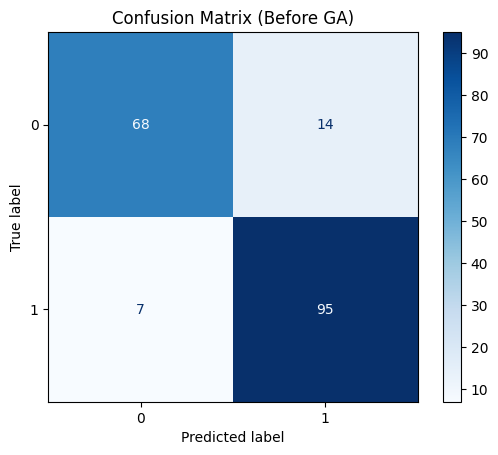

In [ ]:
# Confusion Matrix before GA
cm_before = confusion_matrix(y_test, y_pred)
disp_before = ConfusionMatrixDisplay(confusion_matrix=cm_before)
disp_before.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix (Before GA)")
plt.show()


**Genetic Algorithm for Feature Selection**

In [ ]:
n_features = X_train.shape[1]
POP_SIZE = 20
GENERATIONS = 10
CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.05

def fitness(individual):
    selected = [i for i in range(n_features) if individual[i] == 1]
    if len(selected) == 0:
        return 0
    X_tr = X_train.iloc[:, selected]
    X_te = X_test.iloc[:, selected]
    model = SVC(kernel="rbf", C=1.0, gamma="scale")
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)
    return accuracy_score(y_test, pred)

# Initialize population
population = [[random.randint(0,1) for _ in range(n_features)] for _ in range(POP_SIZE)]

# Evolve population
for gen in range(GENERATIONS):
    fits = [fitness(ind) for ind in population]
    print(f"Gen {gen+1}: best={max(fits):.4f}")

    new_pop = []
    for _ in range(POP_SIZE):
        a,b = random.sample(range(POP_SIZE),2)
        winner = population[a] if fits[a] > fits[b] else population[b]
        new_pop.append(winner.copy())

    # Crossover
    for i in range(0, POP_SIZE,2):
        if random.random() < CROSSOVER_RATE:
            point = random.randint(1, n_features-1)
            new_pop[i][:point], new_pop[i+1][:point] = new_pop[i+1][:point], new_pop[i][:point]

    # Mutation
    for ind in new_pop:
        for j in range(n_features):
            if random.random() < MUTATION_RATE:
                ind[j] = 1 - ind[j]

    population = new_pop

# Best individual
fitnesses = [fitness(ind) for ind in population]
best_individual = population[np.argmax(fitnesses)]
selected_features = [X_train.columns[i] for i in range(n_features) if best_individual[i]==1]

print("\n=== SELECTED FEATURES BY GA ===")
print(f"Number of selected features: {len(selected_features)}")
print(selected_features)


Gen 1: best=0.8967
Gen 2: best=0.9076
Gen 3: best=0.9076
Gen 4: best=0.8967
Gen 5: best=0.8967
Gen 6: best=0.9022
Gen 7: best=0.9022
Gen 8: best=0.9022
Gen 9: best=0.9076
Gen 10: best=0.9185

=== SELECTED FEATURES BY GA ===
Number of selected features: 12
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'Oldpeak', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_TA', 'RestingECG_LVH', 'ExerciseAngina_N', 'ST_Slope_Flat', 'ST_Slope_Up']


**SVM After GA + Metrics**

In [ ]:
if len(selected_features) > 0:
    X_train_red = X_train[selected_features]
    X_test_red  = X_test[selected_features]

    svm2 = SVC(kernel="rbf", C=1.0, gamma="scale")
    svm2.fit(X_train_red, y_train)
    y_pred2 = svm2.predict(X_test_red)

    # Metrics
    red_acc  = accuracy_score(y_test, y_pred2)
    red_prec = precision_score(y_test, y_pred2, average='weighted', zero_division=0)
    red_rec  = recall_score(y_test, y_pred2, average='weighted', zero_division=0)
    red_f1   = f1_score(y_test, y_pred2, average='weighted', zero_division=0)

    print("\n=== GA-REDUCED SVM RESULTS ===")
    print(f"Accuracy:  {red_acc:.4f}")
    print(f"Precision: {red_prec:.4f}")
    print(f"Recall:    {red_rec:.4f}")
    print(f"F1 Score:  {red_f1:.4f}")



=== GA-REDUCED SVM RESULTS ===
Accuracy:  0.9022
Precision: 0.9059
Recall:    0.9022
F1 Score:  0.9013


**Confusion Matrix After GA**

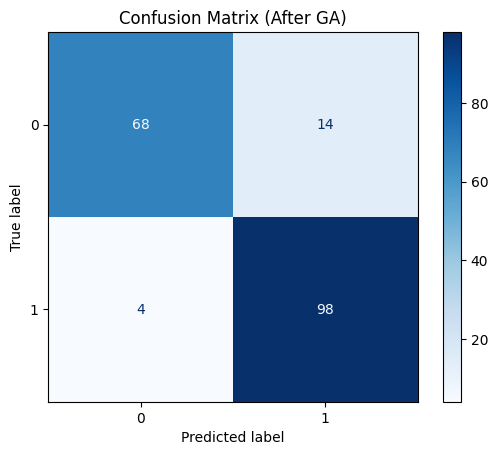

In [ ]:
if len(selected_features) > 0:
    cm_after = confusion_matrix(y_test, y_pred2)
    disp_after = ConfusionMatrixDisplay(confusion_matrix=cm_after)
    disp_after.plot(cmap="Blues", values_format='d')
    plt.title("Confusion Matrix (After GA)")
    plt.show()
else:
    print("\nNo features were selected by GA.")
